In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [47]:
# Project paths
project_root = Path("..")

processed_path = project_root / "data" / "processed"
reports_path = project_root / "reports"

print(processed_path)
print(reports_path)

..\data\processed
..\reports


In [48]:
# Load datasets

nav = pd.read_csv(processed_path / "nav_history_clean.csv")
transactions = pd.read_csv(processed_path / "investor_transactions_clean.csv")
portfolio = pd.read_csv(processed_path / "portfolio_holdings_clean.csv")
scorecard = pd.read_csv(processed_path / "fund_scorecard.csv")

print("NAV:", nav.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)
print("Scorecard:", scorecard.shape)

NAV: (46000, 3)
Transactions: (32778, 13)
Portfolio: (322, 8)
Scorecard: (40, 17)


In [49]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [50]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [51]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [52]:
nav["date"] = pd.to_datetime(nav["date"])

In [53]:
nav = nav.sort_values(["amfi_code", "date"])

In [54]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [55]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [56]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [57]:
# Historical VaR (95%) and CVaR

var_cvar = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    # Historical VaR (5th percentile)
    var95 = returns.quantile(0.05)

    # Conditional VaR
    cvar95 = returns[returns <= var95].mean()

    var_cvar.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar = pd.DataFrame(var_cvar)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [58]:
var_cvar.shape

(40, 3)

In [59]:
print(var_cvar)

    amfi_code    VaR_95   CVaR_95
0      100016 -0.014364 -0.018060
1      100025 -0.003793 -0.004994
2      100033 -0.019034 -0.023456
3      101206 -0.013282 -0.017439
4      101207 -0.026021 -0.032459
5      101208 -0.000269 -0.000422
6      102885 -0.012613 -0.015490
7      102886 -0.019220 -0.023251
8      102887 -0.015232 -0.019411
9      118632 -0.013954 -0.017619
10     118633 -0.013443 -0.016630
11     118634 -0.025438 -0.032304
12     118635 -0.012554 -0.016177
13     118636 -0.003804 -0.004919
14     119092 -0.013750 -0.017328
15     119093 -0.014226 -0.017487
16     119094 -0.018480 -0.024260
17     119095 -0.026188 -0.031667
18     119120 -0.003938 -0.005014
19     119551 -0.012846 -0.016397
20     119552 -0.013501 -0.017336
21     119598 -0.024507 -0.030595
22     119599 -0.026859 -0.032384
23     120503 -0.013550 -0.017451
24     120504 -0.013728 -0.017494
25     120505 -0.018892 -0.024342
26     120506 -0.014388 -0.019405
27     120507 -0.000222 -0.000373
28     120841 

In [60]:
var_cvar.describe()

,amfi_code,VaR_95,CVaR_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [61]:
var_cvar.to_csv(
    processed_path / "var_cvar_report.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [62]:
scorecard.columns.tolist()

['amfi_code',
 'annual_return',
 'annual_volatility',
 'sharpe_ratio',
 'scheme_name',
 'downside_volatility',
 'sortino_ratio',
 'beta',
 'alpha',
 'max_drawdown',
 'cagr',
 'rank_cagr',
 'rank_sharpe',
 'rank_sortino',
 'rank_alpha',
 'rank_drawdown',
 'overall_score']

In [63]:
scorecard.head()

,amfi_code,annual_return,annual_volatility,sharpe_ratio,scheme_name,downside_volatility,sortino_ratio,beta,alpha,max_drawdown,cagr,rank_cagr,rank_sharpe,rank_sortino,rank_alpha,rank_drawdown,overall_score
0,148567,0.270566,0.141937,1.413064,Mirae Asset Large Cap Fund - Regular - Growth,0.086168,2.327618,-0.028133,0.001076,-0.112657,0.270566,7.0,1.0,1.0,7.0,8.0,24.0
1,120843,0.272602,0.158870,1.275272,Kotak Flexicap Fund - Regular - Growth,0.087806,2.307377,-0.008737,0.001082,-0.129740,0.272602,5.0,2.0,2.0,5.0,13.0,27.0
2,148569,0.283262,0.176740,1.206640,Mirae Asset Tax Saver Fund - Regular - Growth,0.101663,2.097732,-0.010201,0.001125,-0.163967,0.283262,4.0,3.0,3.0,4.0,21.0,35.0
3,120505,0.292653,0.192909,1.154182,ICICI Pru Midcap Fund - Regular - Growth,0.112180,1.984782,-0.017391,0.001163,-0.181885,0.292653,3.0,5.0,5.0,3.0,25.0,41.0
4,119551,0.231033,0.137414,1.171880,SBI Bluechip Fund - Regular Plan - Growth,0.077576,2.075814,-0.056045,0.000921,-0.150124,0.231033,10.0,4.0,4.0,10.0,17.0,45.0


In [64]:
# ----------------------------------------
# Rolling 90-Day Sharpe Ratio
# ----------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load NAV data
nav = pd.read_csv(processed_path / "nav_history_clean.csv")

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Daily Returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [65]:
# ----------------------------------------
# Calculate Rolling 90-Day Sharpe Ratio
# ----------------------------------------

# Rolling Mean
nav["rolling_mean"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(90).mean())
)

# Rolling Standard Deviation
nav["rolling_std"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(90).std())
)

# Rolling Sharpe Ratio
nav["rolling_sharpe"] = (
    nav["rolling_mean"] / nav["rolling_std"]
) * np.sqrt(252)

print(nav[["amfi_code", "date", "rolling_sharpe"]].head(100))

      amfi_code       date  rolling_sharpe
5750     100016 2022-01-03             NaN
5751     100016 2022-01-04             NaN
5752     100016 2022-01-05             NaN
5753     100016 2022-01-06             NaN
5754     100016 2022-01-07             NaN
...         ...        ...             ...
5845     100016 2022-05-16       -0.419782
5846     100016 2022-05-17       -0.029988
5847     100016 2022-05-18       -0.132298
5848     100016 2022-05-19       -0.194050
5849     100016 2022-05-20       -0.415433

[100 rows x 3 columns]


In [66]:
# ----------------------------------------
# Select 5 Key Funds
# ----------------------------------------

scorecard = pd.read_csv(processed_path / "fund_scorecard.csv")

top5 = scorecard.head(5)["amfi_code"].tolist()

print(top5)

[148567, 120843, 148569, 120505, 119551]


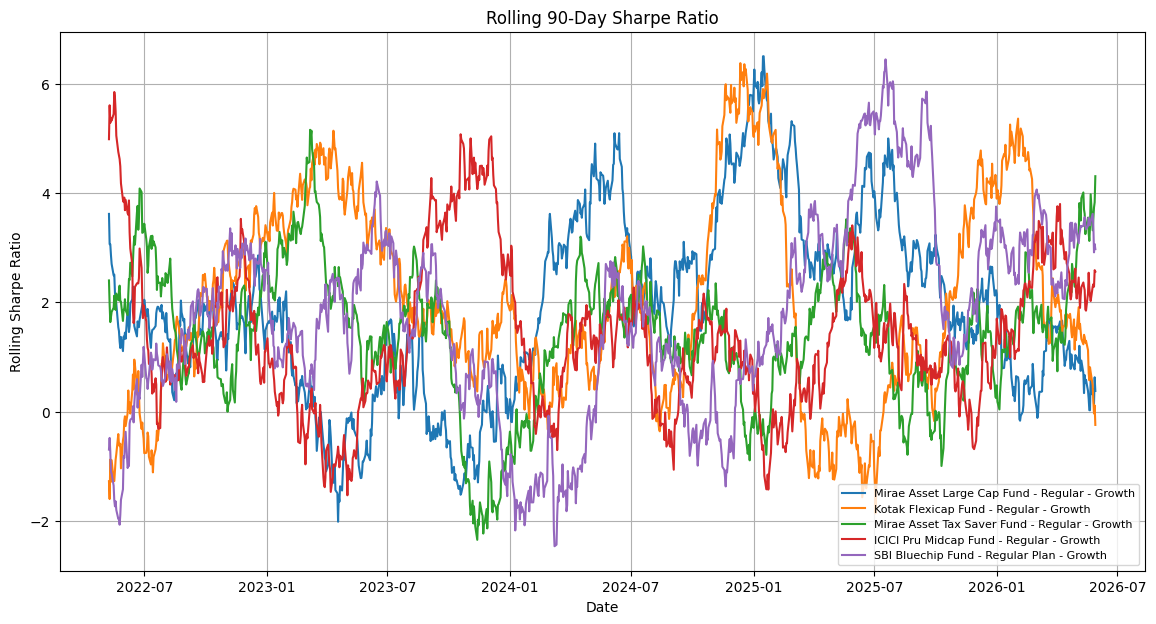

In [67]:
# ----------------------------------------
# Plot Rolling 90-Day Sharpe Ratio
# ----------------------------------------

plt.figure(figsize=(14, 7))

for fund in top5:
    
    fund_data = nav[nav["amfi_code"] == fund]

    # Get scheme name
    scheme_name = scorecard.loc[
        scorecard["amfi_code"] == fund,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=scheme_name
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

# Save chart
plt.savefig(
    reports_path / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [69]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [70]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [71]:
# Convert transaction date to datetime
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [72]:
# First investment date for each investor
first_investment = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_investment.rename(
    columns={"transaction_date": "first_investment_date"},
    inplace=True
)

first_investment.head()

,investor_id,first_investment_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [73]:
# Create cohort month
first_investment["cohort_month"] = (
    first_investment["first_investment_date"]
    .dt.to_period("M")
    .astype(str)
)

first_investment.head()

,investor_id,first_investment_date,cohort_month
0,INV000001,2024-11-04,2024-11
1,INV000002,2024-03-29,2024-03
2,INV000003,2024-07-16,2024-07
3,INV000004,2024-03-16,2024-03
4,INV000005,2024-04-27,2024-04


In [74]:
transactions = transactions.merge(
    first_investment[["investor_id", "cohort_month"]],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_month
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01


In [75]:
# ----------------------------------------
# Investor Cohort Summary
# ----------------------------------------

cohort_summary = (
    transactions.groupby("cohort_month")
    .agg(
        total_investors=("investor_id", "nunique"),
        total_investment=("amount_inr", "sum"),
        average_investment=("amount_inr", "mean")
    )
    .reset_index()
)

cohort_summary

,cohort_month,total_investors,total_investment,average_investment
0,2024-01,1577,1378531351,107337.175971
1,2024-02,990,837486576,109561.299843
2,2024-03,669,481918027,104379.039853
3,2024-04,441,293281266,106647.733091
4,2024-05,294,171335115,107757.933962
5,2024-06,236,124582926,108521.712544
6,2024-07,175,69399857,103120.144131
7,2024-08,135,56349666,114999.318367
8,2024-09,100,29532841,101487.426117
9,2024-10,75,26035364,121094.716279


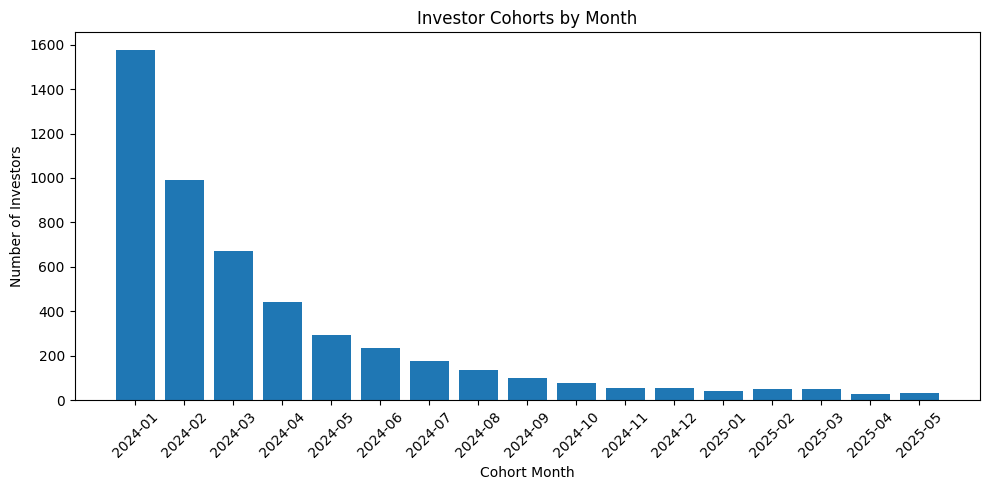

In [76]:
# ----------------------------------------
# Cohort Analysis Chart
# ----------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    cohort_summary["cohort_month"],
    cohort_summary["total_investors"]
)

plt.title("Investor Cohorts by Month")
plt.xlabel("Cohort Month")
plt.ylabel("Number of Investors")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [77]:
# ----------------------------------------
# SIP Transactions Only
# ----------------------------------------

sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

print(sip_txn.shape)

sip_txn.head()

(19716, 14)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_month
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024-01
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024-01


In [78]:
sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

In [79]:
# Gap between SIPs

sip_txn["previous_sip_date"] = (
    sip_txn.groupby("investor_id")["transaction_date"]
    .shift(1)
)

sip_txn["gap_days"] = (
    sip_txn["transaction_date"]
    - sip_txn["previous_sip_date"]
).dt.days

sip_txn[
    ["investor_id",
     "transaction_date",
     "previous_sip_date",
     "gap_days"]
].head(20)

,investor_id,transaction_date,previous_sip_date,gap_days
19621,INV000001,2024-11-04,NaT,NaN
24448,INV000001,2025-01-19,2024-11-04,76.0
5650,INV000002,2024-03-29,NaT,NaN
16803,INV000002,2024-09-21,2024-03-29,176.0
31881,INV000002,2025-05-17,2024-09-21,238.0
12652,INV000003,2024-07-16,NaT,NaN
27622,INV000003,2025-03-11,2024-07-16,238.0
4773,INV000004,2024-03-16,NaT,NaN
6418,INV000004,2024-04-11,2024-03-16,26.0
8271,INV000004,2024-05-09,2024-04-11,28.0


In [80]:
# Investors with gap > 35 days

at_risk = sip_txn[
    sip_txn["gap_days"] > 35
]

print("At Risk Investors:", at_risk["investor_id"].nunique())

at_risk[
    ["investor_id",
     "transaction_date",
     "gap_days"]
].head()

At Risk Investors: 3906


,investor_id,transaction_date,gap_days
24448,INV000001,2025-01-19,76.0
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
27622,INV000003,2025-03-11,238.0
12003,INV000004,2024-07-07,59.0


In [81]:
portfolio.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [82]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [83]:
# ----------------------------------------
# Sector HHI Concentration
# ----------------------------------------

# Convert weights from percentage to decimal
portfolio["weight"] = portfolio["weight_pct"] / 100

# Calculate HHI for each fund
hhi = (
    portfolio.groupby("amfi_code")["weight"]
    .apply(lambda x: (x**2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [84]:
# Add scheme names
hhi = hhi.merge(
    scorecard[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [85]:
# Highest concentration first
hhi = hhi.sort_values("HHI", ascending=False)

hhi

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


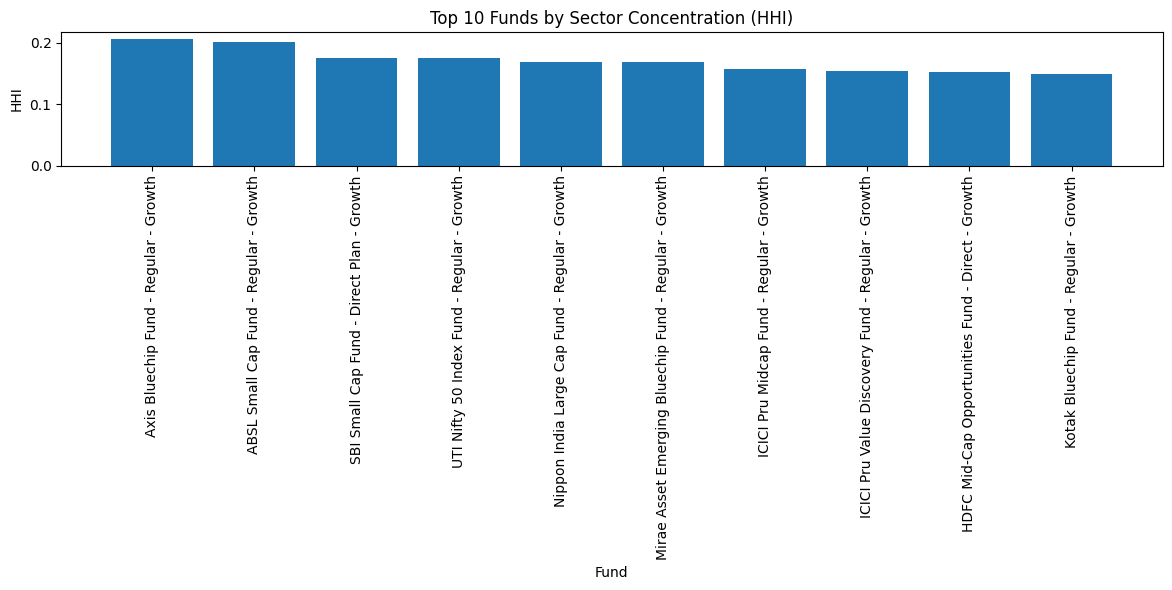

In [86]:
plt.figure(figsize=(12,6))

top10 = hhi.head(10)

plt.bar(top10["scheme_name"], top10["HHI"])

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sector Concentration (HHI)")
plt.xlabel("Fund")
plt.ylabel("HHI")

plt.tight_layout()

plt.show()

In [87]:
hhi.to_csv(
    processed_path / "sector_hhi_report.csv",
    index=False
)

print("sector_hhi_report.csv saved successfully!")

sector_hhi_report.csv saved successfully!


# Advanced Insights

## 1. Value at Risk (VaR) & CVaR
The VaR and CVaR analysis highlights that some mutual funds have significantly higher downside risk than others. Funds with larger negative VaR values are more vulnerable to adverse market movements, while CVaR provides insight into expected losses during extreme scenarios.

---

## 2. Rolling Sharpe Ratio
The rolling 90-day Sharpe Ratio demonstrates that fund performance changes over time. Some funds consistently maintain higher risk-adjusted returns, while others experience greater volatility, making rolling analysis more informative than a single historical metric.

---

## 3. Investor Cohort Analysis
Investor cohort analysis shows how different groups of investors entered the market over time. Comparing cohorts helps identify trends in investor participation and overall investment growth across different periods.

---

## 4. SIP Continuity Analysis
A significant number of investors experienced SIP gaps exceeding 35 days, indicating potential discontinuation or irregular investment behaviour. These investors can be considered at-risk and may benefit from timely engagement or reminder strategies.

---

## 5. Sector Concentration (HHI)
The Herfindahl-Hirschman Index (HHI) indicates the diversification level of each mutual fund portfolio. Funds with higher HHI values are more concentrated in fewer sectors, whereas lower HHI values represent better diversification and potentially lower concentration risk.